In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
simuls = pd.read_csv("simul.csv")
data_long = simuls.melt(
    id_vars=[c for c in simuls.columns if not c.startswith("Precision_quantile_")],
    value_vars=[c for c in simuls.columns if c.startswith("Precision_quantile_")],
    var_name="combined",
    value_name="Precision"
)

data_long[["Metric", "Quantile"]] = data_long["combined"].str.extract(r"(.*)_quantile_(.*)")
data_long["Quantile"] = data_long["Quantile"].astype(float).round(4)
data_long = data_long.drop(columns="combined")

[<Axes: > <Axes: > <Axes: > <Axes: >]


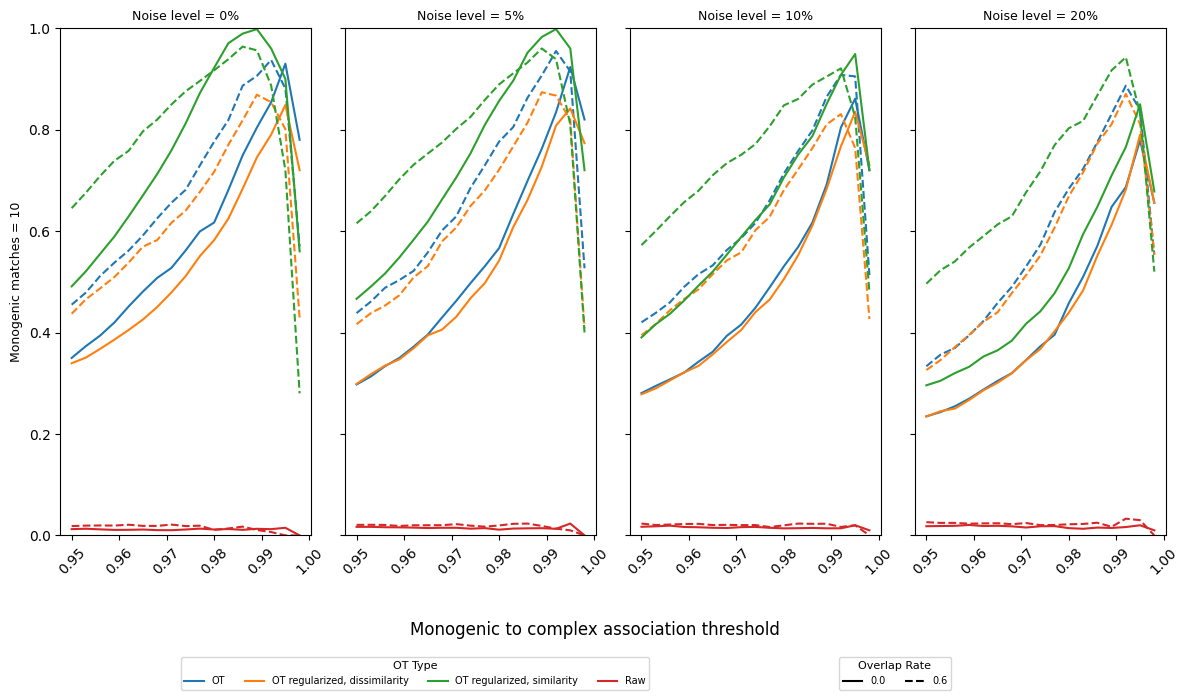

In [22]:
# Valeurs uniques pour la grille
n_matches = sorted(data_long["n_match"].unique())
noise_levels = sorted(data_long["noise_level"].unique())

# Plot
fig, axes = plt.subplots(
    len(n_matches), len(noise_levels),
    figsize=(12, 7),
    sharex=True, sharey=True
)
print(axes)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ot_types = sorted(data_long["OT_type"].unique())
overlap_rates = sorted(data_long["overlap_rate"].unique())
linestyles = ["-", "--", "-.", ":"]

for i, n_match in enumerate(n_matches):
    for j, noise in enumerate(noise_levels):
        if len(n_matches) == 1:
            ax = axes[j]
        elif len(noise_levels) == 1:
            ax = axes[i]
        else:
            ax = axes[i, j]
        subset = data_long[(data_long["n_match"] == n_match) & (data_long["noise_level"] == noise)]

        for k, ot in enumerate(ot_types):
            for l, rate in enumerate(overlap_rates):
                sub = subset[(subset["OT_type"] == ot) & (subset["overlap_rate"] == rate)]
                ax.plot(
                    sub["Quantile"], sub["Precision"],
                    color=colors[k % len(colors)],
                    linestyle=linestyles[l % len(linestyles)],
                    label=f"{ot} / {rate}" if i == 0 and j == 0 else ""
                )

        ax.set_ylim(0, 1)
        ax.tick_params(axis="x", rotation=45)

        if i == 0:
            ax.set_title(f"Noise level = {noise * 100:.0f}%", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"Monogenic matches = {n_match}", fontsize=9)

# Légendes séparées pour OT_type et overlap_rate
ot_handles = [plt.Line2D([0], [0], color=colors[k % len(colors)], label=str(ot)) for k, ot in enumerate(ot_types)]
rate_handles = [plt.Line2D([0], [0], color="black", linestyle=linestyles[l % len(linestyles)], label=str(r)) for l, r in enumerate(overlap_rates)]

fig.legend(handles=ot_handles, loc="lower center", ncol=len(ot_types), bbox_to_anchor=(0.35, 0), fontsize=7, title="OT Type", title_fontsize=8)
fig.legend(handles=rate_handles, loc="lower center", ncol=len(overlap_rates), bbox_to_anchor=(0.75, 0), fontsize=7, title="Overlap Rate", title_fontsize=8)

fig.supxlabel("Monogenic to complex association threshold", y=0.08)
plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()